# Mapbox Traffic + Streets Tile Fetcher

This notebook fetches two Mapbox tilesets and joins them to produce a full road network with traffic congestion data — similar to what OSM-based traffic maps show.

## Why two tilesets?

| Tileset | Layer | What it has | What it lacks |
|---|---|---|---|
| `mapbox.mapbox-traffic-v1` | `traffic` | congestion level per segment | only covers roads with live sensor/GPS data |
| `mapbox.mapbox-streets-v8` | `road` | **all** roads (same source as OSM) | no congestion data |

By joining them spatially we get: every road from the streets tileset, with congestion data attached where available.

## Pipeline

```
boundary.geojson
      │
      ▼
① Find which tiles cover the boundary
      │
      ├──▶ ② Download mapbox-streets-v8 tiles  →  all road geometry
      │
      └──▶ ③ Download mapbox-traffic-v1 tiles  →  congestion per segment
      │
      ▼
④ Decode both .mvt tiles  →  two GeoDataFrames in WGS-84
      │
      ▼
⑤ Spatial join: match each street to its nearest traffic segment (≤ 20 m)
      │
      ▼
⑥ Clip to boundary  →  visualize + save
```

## Coordinate system inside a tile

Both tilesets use the Mapbox Vector Tile (MVT) format.  
Coordinates are integers in tile-pixel space. Origin `(0,0)` = **north-west** corner; x increases east, y increases south.

```
lon = west  + (x / extent) × (east  − west)
lat = north − (y / extent) × (north − south)
```

> **Note on `y_coord_down`:** The `mapbox_vector_tile` library flips y by default (`y_coord_down=False`), which gives wrong coordinates when combined with the formula above. We pass `y_coord_down=True` to keep raw MVT y values.

In [1]:
%pip install mercantile mapbox-vector-tile python-dotenv folium --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
%%time
import os
import time
from pathlib import Path

import mercantile
import requests
import mapbox_vector_tile
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from shapely.affinity import affine_transform
from shapely.geometry import box, mapping, shape

load_dotenv(Path('../.env'), override=True)

# ── Configuration ────────────────────────────────────────────────────────────
MAPBOX_TOKEN   = os.environ.get('MAPBOX_ACCESS_TOKEN', '')
GEOJSON_PATH   = '../boundaries/sodermalm.geojson'
ZOOM           = 14     # 14-15 gives OSM-like road density
TILES_DIR      = Path('../tiles')
DECODED_DIR    = Path('../decoded')
OUTPUT_DIR     = Path('../output')

TRAFFIC_URL = 'https://api.mapbox.com/v4/mapbox.mapbox-traffic-v1/{z}/{x}/{y}.mvt'
STREETS_URL = 'https://api.mapbox.com/v4/mapbox.mapbox-streets-v8/{z}/{x}/{y}.mvt'
# ─────────────────────────────────────────────────────────────────────────────

# Derive output filenames from the boundary file name
boundary_name = Path(GEOJSON_PATH).stem          # e.g. 'sodermalm'
OUTPUT_FILE   = OUTPUT_DIR / f'{boundary_name}_traffic.geojson'
OUTPUT_CSV    = OUTPUT_DIR / f'{boundary_name}_traffic.csv'

(TILES_DIR   / 'traffic').mkdir(parents=True, exist_ok=True)
(TILES_DIR   / 'streets').mkdir(parents=True, exist_ok=True)
DECODED_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

if not MAPBOX_TOKEN:
    print('Token not set — add MAPBOX_ACCESS_TOKEN=pk.eyJ1... to ../.env')
else:
    print(f'Token OK: {MAPBOX_TOKEN[:8]}...{MAPBOX_TOKEN[-4:]}')
print(f'Boundary: {boundary_name}')
print(f'Output:   {OUTPUT_FILE}')

Token not set — add MAPBOX_ACCESS_TOKEN=pk.eyJ1... to ../.env
Boundary: sodermalm
Output:   ../output/sodermalm_traffic.geojson
CPU times: user 2.09 s, sys: 74.1 ms, total: 2.16 s
Wall time: 647 ms


---
## Step 1 — Load boundary

Boundary:  W=18.02607  S=59.30321  E=18.10717  N=59.32139


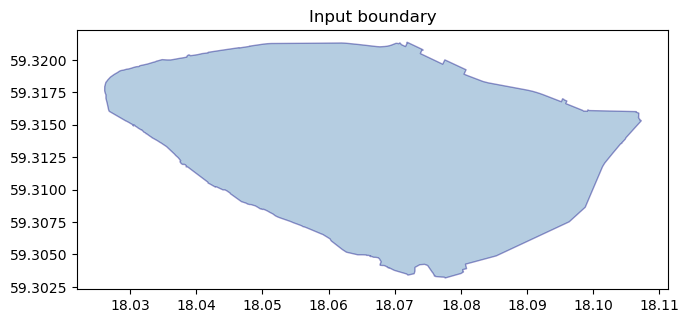

CPU times: user 110 ms, sys: 0 ns, total: 110 ms
Wall time: 155 ms


In [3]:
%%time
gdf      = gpd.read_file(GEOJSON_PATH).to_crs('EPSG:4326')
boundary = gdf.geometry.union_all()
west, south, east, north = boundary.bounds

print(f'Boundary:  W={west:.5f}  S={south:.5f}  E={east:.5f}  N={north:.5f}')

ax = gdf.plot(figsize=(7, 5), color='steelblue', alpha=0.4, edgecolor='navy')
ax.set_title('Input boundary')
plt.tight_layout()
plt.show()

---
## Step 2 — Find tiles

At zoom 14 the world is a 16 384 × 16 384 grid — each tile is ~2 km wide at this latitude, giving OSM-level road detail.

In [4]:
%%time
candidate_tiles = list(mercantile.tiles(west, south, east, north, zooms=ZOOM))
tiles = [t for t in candidate_tiles
         if boundary.intersects(box(*mercantile.bounds(t)))]

print(f'Zoom {ZOOM}: {len(candidate_tiles)} bbox tiles → {len(tiles)} intersect boundary')
for t in tiles:
    b = mercantile.bounds(t)
    print(f'  {t}  W={b.west:.4f} S={b.south:.4f} E={b.east:.4f} N={b.north:.4f}')

Zoom 14: 10 bbox tiles → 8 intersect boundary
  Tile(x=9012, y=4819, z=14)  W=18.0176 S=59.3108 E=18.0396 N=59.3220
  Tile(x=9013, y=4819, z=14)  W=18.0396 S=59.3108 E=18.0615 N=59.3220
  Tile(x=9013, y=4820, z=14)  W=18.0396 S=59.2996 E=18.0615 N=59.3108
  Tile(x=9014, y=4819, z=14)  W=18.0615 S=59.3108 E=18.0835 N=59.3220
  Tile(x=9014, y=4820, z=14)  W=18.0615 S=59.2996 E=18.0835 N=59.3108
  Tile(x=9015, y=4819, z=14)  W=18.0835 S=59.3108 E=18.1055 N=59.3220
  Tile(x=9015, y=4820, z=14)  W=18.0835 S=59.2996 E=18.1055 N=59.3108
  Tile(x=9016, y=4819, z=14)  W=18.1055 S=59.3108 E=18.1274 N=59.3220
CPU times: user 1.02 ms, sys: 0 ns, total: 1.02 ms
Wall time: 1.22 ms


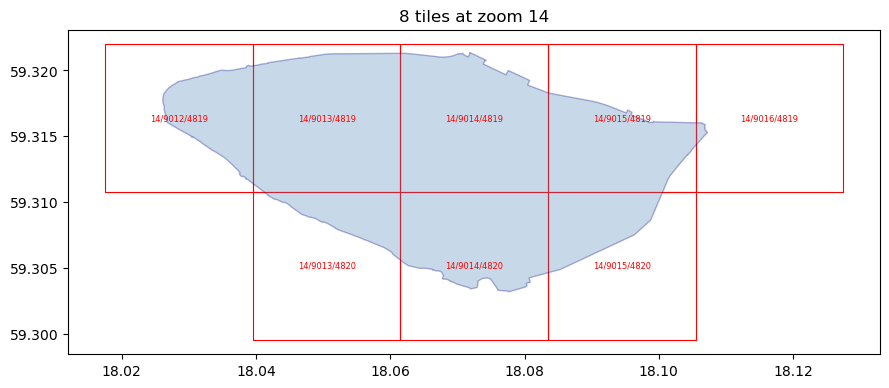

CPU times: user 83.4 ms, sys: 3.16 ms, total: 86.6 ms
Wall time: 86.3 ms


In [5]:
%%time
tile_gdf = gpd.GeoDataFrame(
    [{'z': t.z, 'x': t.x, 'y': t.y} for t in tiles],
    geometry=[box(*mercantile.bounds(t)) for t in tiles],
    crs='EPSG:4326',
)
fig, ax = plt.subplots(figsize=(9, 7))
tile_gdf.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.8)
gdf.plot(ax=ax, color='steelblue', alpha=0.3, edgecolor='navy')
for _, row in tile_gdf.iterrows():
    c = row.geometry.centroid
    ax.text(c.x, c.y, f"{row['z']}/{row['x']}/{row['y']}",
            ha='center', va='center', fontsize=6, color='red')
ax.set_title(f'{len(tiles)} tiles at zoom {ZOOM}')
plt.tight_layout()
plt.show()

---
## Step 3 — Download tiles (both tilesets)

We download two `.mvt` files per tile:
- `tiles/traffic/{z}_{x}_{y}.mvt` — congestion data
- `tiles/streets/{z}_{x}_{y}.mvt` — all road geometry

Already-cached tiles are skipped on re-runs.

In [6]:
%%time
from concurrent.futures import ThreadPoolExecutor, as_completed

def download_tile(url_template, tile, out_dir, token, retries=3):
    """Download one .mvt tile. Returns Path on success, None on failure.
    Cached files are returned immediately without a network call.
    """
    path = out_dir / f'{tile.z}_{tile.x}_{tile.y}.mvt'
    if path.exists():
        return tile, path
    url = url_template.format(z=tile.z, x=tile.x, y=tile.y)
    for attempt in range(retries):
        try:
            r = requests.get(url, params={'access_token': token}, timeout=(5, 20))
        except requests.exceptions.Timeout:
            time.sleep(2 ** attempt)
            continue
        except requests.exceptions.RequestException as e:
            print(f'  network error {tile}: {e}')
            return tile, None
        if r.status_code == 200:
            path.write_bytes(r.content)
            return tile, path
        if r.status_code == 429:
            time.sleep(2 ** attempt)
        else:
            print(f'  {tile} HTTP {r.status_code}: {r.text[:80]}')
            return tile, None
    return tile, None


def download_tileset(url_template, tiles, out_dir, token, label, workers=6):
    """Download all tiles in parallel. Returns dict of tile → Path."""
    results = {}
    futures = {}
    with ThreadPoolExecutor(max_workers=workers) as pool:
        for tile in tiles:
            f = pool.submit(download_tile, url_template, tile, out_dir, token)
            futures[f] = tile
        for f in as_completed(futures):
            tile, path = f.result()
            if path:
                results[tile] = path
                cached = '(cached)' if not path.stat().st_mtime else ''
                print(f'  [{label}] {tile} → {path.stat().st_size:,} bytes {cached}')
            else:
                print(f'  [{label}] {tile} → FAILED')
    return results


print(f'Downloading {len(tiles)} tiles × 2 tilesets in parallel...\n')
traffic_paths = download_tileset(TRAFFIC_URL, tiles, TILES_DIR / 'traffic', MAPBOX_TOKEN, 'traffic')
streets_paths = download_tileset(STREETS_URL, tiles, TILES_DIR / 'streets', MAPBOX_TOKEN, 'streets')

print(f'\nTraffic tiles ready: {len(traffic_paths)}/{len(tiles)}')
print(f'Streets tiles ready: {len(streets_paths)}/{len(tiles)}')


  Tile(x=9012, y=4819, z=14) HTTP 401: {"message": "Not Authorized",  "error_detail": "Direct access not allowed"}
  [traffic] Tile(x=9012, y=4819, z=14) → FAILED
  Tile(x=9014, y=4819, z=14) HTTP 401: {"message": "Not Authorized",  "error_detail": "Direct access not allowed"}
  [traffic] Tile(x=9014, y=4819, z=14) → FAILED
  Tile(x=9013, y=4819, z=14) HTTP 401: {"message": "Not Authorized",  "error_detail": "Direct access not allowed"}
  [traffic] Tile(x=9013, y=4819, z=14) → FAILED
  Tile(x=9013, y=4820, z=14) HTTP 401: {"message": "Not Authorized",  "error_detail": "Direct access not allowed"}
  [traffic] Tile(x=9013, y=4820, z=14) → FAILED
  Tile(x=9015, y=4819, z=14) HTTP 401: {"message": "Not Authorized",  "error_detail": "Direct access not allowed"}
  [traffic] Tile(x=9015, y=4819, z=14) → FAILED
  Tile(x=9014, y=4820, z=14) HTTP 401: {"message": "Not Authorized",  "error_detail": "Direct access not allowed"}
  [traffic] Tile(x=9014, y=4820, z=14) → FAILED
  Tile(x=9015, y=4820

---
## Step 4 — Decode both tilesets

Both tilesets use the same MVT binary format but different layer names and extents:

| Tileset | Layer name | Typical extent | Key properties |
|---|---|---|---|
| `mapbox-traffic-v1` | `traffic` | 262 144 | `congestion`, `class` |
| `mapbox-streets-v8` | `road` | 4 096 | `class`, `type`, `name`, `oneway`, `structure` |

We decode with `y_coord_down=True` to keep raw MVT y (y=0 = north edge), then apply:
```
lon = west  + (x / extent) × (east  − west)
lat = north − (y / extent) × (north − south)
```

In [7]:
%%time
def decode_mvt(pbf_path, tile, layer_name):
    """
    Decode one .mvt tile and return a list of GeoJSON-style feature dicts
    with coordinates in WGS-84 lon/lat.

    y_coord_down=True: keep raw MVT y (y=0 at north, increases south).
    The library default (y_coord_down=False) flips y, which gives wrong
    coordinates when combined with the affine transform below.
    """
    data    = pbf_path.read_bytes()
    decoded = mapbox_vector_tile.decode(data, default_options={'y_coord_down': True})
    layer   = decoded.get(layer_name, {})
    extent  = layer.get('extent', 4096)

    b  = mercantile.bounds(tile)
    dx = (b.east  - b.west)  / extent
    dy = (b.north - b.south) / extent
    matrix = [dx, 0, 0, -dy, b.west, b.north]

    features = []
    for feat in layer.get('features', []):
        geom = affine_transform(shape(feat['geometry']), matrix)
        features.append({
            'type': 'Feature',
            'geometry': mapping(geom),
            'properties': {
                **feat['properties'],
                'tile': f'{tile.z}/{tile.x}/{tile.y}',
            },
        })
    return features


# ── Decode traffic tiles ──────────────────────────────────────────────────
print('Decoding traffic tiles...')
traffic_features = []
for tile, path in traffic_paths.items():
    feats = decode_mvt(path, tile, layer_name='traffic')
    traffic_features.extend(feats)
    out = DECODED_DIR / f'traffic_{tile.z}_{tile.x}_{tile.y}.geojson'
    (
        gpd.GeoDataFrame.from_features(feats, crs='EPSG:4326')
           .explode(index_parts=False)
           .reset_index(drop=True)
           .to_file(out, driver='GeoJSON')
    )
    print(f'  {tile}  traffic → {len(feats)} features  saved {out.name}')

# ── Decode streets tiles ──────────────────────────────────────────────────
print('\nDecoding streets tiles...')
streets_features = []
for tile, path in streets_paths.items():
    feats = decode_mvt(path, tile, layer_name='road')
    streets_features.extend(feats)
    out = DECODED_DIR / f'streets_{tile.z}_{tile.x}_{tile.y}.geojson'
    (
        gpd.GeoDataFrame.from_features(feats, crs='EPSG:4326')
           .explode(index_parts=False)
           .reset_index(drop=True)
           .to_file(out, driver='GeoJSON')
    )
    print(f'  {tile}  streets → {len(feats)} features  saved {out.name}')

print(f'\nTotal traffic features: {len(traffic_features)}')
print(f'Total streets features: {len(streets_features)}')

Decoding traffic tiles...

Decoding streets tiles...

Total traffic features: 0
Total streets features: 0
CPU times: user 118 μs, sys: 7 μs, total: 125 μs
Wall time: 121 μs


---
## Step 5 — Join streets + traffic by proximity

Both tilesets reference the same OSM road network, so segments overlap closely.  
We reproject to **EPSG:3857** (metres) and use `sjoin_nearest` to attach the congestion level of the nearest traffic segment (within 20 m) to each street segment.  
Streets with no nearby traffic segment get `congestion = 'no data'`.

In [ ]:
%%time
if not streets_features:
    raise RuntimeError(
        'No streets features decoded — check that:\n'
        '  1. MAPBOX_TOKEN is set (config cell shows "Token OK")\n'
        '  2. Tiles downloaded successfully (download cell shows no FAILED lines)\n'
        '  3. Re-run the download cell if needed'
    )

streets_gdf = (
    gpd.GeoDataFrame.from_features(streets_features, crs='EPSG:4326')
       .explode(index_parts=False)
       .reset_index(drop=True)
)
traffic_gdf = (
    gpd.GeoDataFrame.from_features(traffic_features, crs='EPSG:4326')
       .explode(index_parts=False)
       .reset_index(drop=True)
) if traffic_features else gpd.GeoDataFrame(columns=['congestion', 'geometry'])

print(f'Streets segments: {len(streets_gdf)}')
print(f'Traffic segments: {len(traffic_gdf)}')
print(f'Street classes:   {sorted(streets_gdf["class"].unique())}')

streets_m = streets_gdf.to_crs('EPSG:3857')
traffic_m = traffic_gdf[['congestion', 'geometry']].to_crs('EPSG:3857') if len(traffic_gdf) else traffic_gdf

joined_m = gpd.sjoin_nearest(
    streets_m,
    traffic_m,
    how='left',
    max_distance=20,
    distance_col='_dist',
).drop(columns=['index_right', '_dist'], errors='ignore')

joined_m = joined_m[~joined_m.index.duplicated(keep='first')]
joined = joined_m.to_crs('EPSG:4326')
joined['congestion'] = joined['congestion'].fillna('no data')

print(f'\nJoined segments: {len(joined)}')
print('\nCongestion breakdown:')
print(joined['congestion'].value_counts().to_string())

---
## Step 6 — Clip to boundary

In [9]:
%%time
clipped = gpd.clip(joined, gdf)

print(f'Segments after clip: {len(clipped)}')
print('\nCongestion breakdown:')
print(clipped['congestion'].value_counts().to_string())
print('\nRoad class breakdown:')
print(clipped['class'].value_counts().to_string())

NameError: name 'joined' is not defined

---
## Step 7 — Visualize

All roads from the streets tileset are shown.  
Color = congestion level where Mapbox has live data; gray = no traffic data for that segment.

| Color | Congestion |
|---|---|
| 🟢 Green | low |
| 🟠 Orange | moderate |
| 🔴 Red | heavy |
| ⬛ Dark red | severe |
| ⬜ Gray | no data |

In [10]:
%%time
CONGESTION_COLORS = {
    'low':      '#00c800',
    'moderate': '#ffa500',
    'heavy':    '#ff4500',
    'severe':   '#8b0000',
    'no data':  '#aaaaaa',
}

# Keep only line geometries — the streets tileset also contains point features
# (traffic_signals, stop_sign, turning_circle, yield_sign) which folium would
# render as circle markers. We only want roads.
lines = clipped[clipped.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
print(f'Line segments to draw: {len(lines)}  (dropped {len(clipped) - len(lines)} point features)')

center = [(south + north) / 2, (west + east) / 2]
m = folium.Map(location=center, zoom_start=14, tiles='OpenStreetMap')

folium.GeoJson(
    gdf.__geo_interface__,
    style_function=lambda _: {'color': 'navy', 'weight': 2, 'fillOpacity': 0.05},
    tooltip=None,
    popup=None,
    name='Boundary',
).add_to(m)

folium.GeoJson(
    lines.__geo_interface__,
    style_function=lambda feat: {
        'color':  CONGESTION_COLORS.get(
                      feat['properties'].get('congestion', 'no data'), '#aaaaaa'),
        'weight': 3 if feat['properties'].get('congestion', 'no data') != 'no data' else 1.5,
    },
    tooltip=None,
    popup=None,
    name='Traffic',
).add_to(m)

folium.LayerControl().add_to(m)
m

NameError: name 'clipped' is not defined

---
## Step 8 — Save

| File | Contents |
|---|---|
| `traffic.geojson` | All road segments with congestion (or 'no data') |
| `traffic.csv` | Same, without geometry |

In [11]:
%%time
import numpy as np
from shapely import get_coordinates

# ── GeoJSON ───────────────────────────────────────────────────────────────
clipped.to_file(OUTPUT_FILE, driver='GeoJSON')
print(f'Saved GeoJSON → {OUTPUT_FILE}  ({len(clipped)} segments)')

# ── CSV ───────────────────────────────────────────────────────────────────
csv_df = clipped.drop(columns='geometry').copy()

clipped_m = clipped.to_crs('EPSG:3857')

centroids     = clipped_m.geometry.centroid.to_crs('EPSG:4326')
csv_df['lon'] = centroids.x.round(6)
csv_df['lat'] = centroids.y.round(6)

all_coords          = clipped.geometry.apply(get_coordinates)
csv_df['start_lon'] = all_coords.apply(lambda c: round(c[ 0][0], 6))
csv_df['start_lat'] = all_coords.apply(lambda c: round(c[ 0][1], 6))
csv_df['end_lon']   = all_coords.apply(lambda c: round(c[-1][0], 6))
csv_df['end_lat']   = all_coords.apply(lambda c: round(c[-1][1], 6))
csv_df['length_m']  = clipped_m.geometry.length.round(1)

csv_df.to_csv(OUTPUT_CSV, index=False)
print(f'Saved CSV     → {OUTPUT_CSV}')

print()
display(csv_df.head(10))

NameError: name 'clipped' is not defined